In this Notebook the data created by "data_preparation" will be used as input for the models!

## Importing the required libraries

In [57]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

import statsmodels.api as sm
from linearmodels import PanelOLS, RandomEffects, PooledOLS
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2, jarque_bera

countries = ["Austria", "Belgium", "Bulgaria", "Croatia", "Czechia", "Denmark", 
             "Estonia", "Finland", "France", "Germany", "Greece", "Hungary", "Ireland", 
             "Italy", "Latvia", "Lithuania", "Luxembourg", "Norway", "Poland",
             "Portugal", "Romania", "Slovakia", "Slovenia", "Spain", "Sweden", "Netherlands",
             #"Germany including former GDR",
             #"Cyprus", "Malta",
             ]

country_codes = {
"Austria"        :"AT",
"Belgium"        :"BE",
"Bulgaria"       :"BG",
"Cyprus"         :"CY",
"Czechia"        :"CZ",
"Germany"        :"DE",
"Denmark"        :"DK",
"Estonia"        :"EE",
"Greece"         :"EL",
"Spain"          :"ES",
"Finland"        :"FI",
"France"         :"FR",
"Croatia"        :"HR",
"Hungary"        :"HU",
"Ireland"        :"IE",
"Italy"          :"IT",
"Lithuania"      :"LT",
"Luxembourg"     :"LU",
"Latvia"         :"LV",
"Malta"          :"MT",
"Netherlands"    :"NL",
"Norway"         :"NO",
"Poland"         :"PL",
"Portugal"       :"PT",
"Romania"        :"RO",
"Sweden"         :"SE",
"Slovenia"       :"SI",
"Slovakia"       :"SK",
}

years = [1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000,
       2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030,
       2035, 2040, 2045, 2050, 2055, 2060]

print("Total number of countries considered:")
len(countries) - 1 # Germany mentioned two times

Total number of countries considered:


25

## Data Preparation --> hist ; (train, val), proj

In [58]:
panel = pd.read_csv("Data - raw/prepared_data/panel_transformed.csv", index_col=[0, 1])

# PanelOLS Model expects (entity, time) index!
panel = panel.reorder_levels(['country', 'year']).sort_index()

hist = panel[panel["demand_oth_TWh"].notna()].copy()
proj = panel[panel["demand_oth_TWh"].isna()].copy()


TRAIN_END = 2022
VAL_START = 2023
PROJ_START = 2025
 
train = panel[panel.index.get_level_values("year") <= TRAIN_END]
val   = panel[panel.index.get_level_values("year") >= VAL_START]

print(f"\nTrain: {hist.index.get_level_values('year').min()}–{TRAIN_END}  ({len(train)} obs)")
print(f"Val  : {VAL_START}–{hist.index.get_level_values('year').max()}  ({len(val)} obs)")

proj


Train: 1990–2022  (858 obs)
Val  : 2023–2024  (364 obs)


population_Mio  gdp_per_capita_USD  hdd_DegreesC  cdd_DegreesC  \
country year                                                                   
Austria 2025        9.197213         62963.14442   3379.147461     27.660344   
        2026        9.219116         63580.49807   3732.406812     33.347582   
        2027        9.234675         64983.96000   3906.658279     60.987898   
        2028        9.251146         66031.00000   3633.106417     53.175922   
        2029        9.268632         66898.02000   3350.720557     72.931122   
...                      ...                 ...           ...           ...   
Sweden  2040       11.108521         81496.18000   4191.824255      1.805832   
        2045       11.293147         87990.98000   4059.818221      8.479975   
        2050       11.457559         94148.38000   3827.886324      7.947360   
        2055       11.584352        100097.00000   4362.839542      8.167766   
        2060       11.667100        106829.70000   4526.402532     11.973012   

              industry_va_MioEUR  energy_intensity_KGOE_per_EUR_PPS  \
country year                                                          
Austria 2025       201073.900000                          70.674200   
        2026       207473.541427                          68.553974   
        2027       214076.866229                          66.497355   
        2028       220890.357098                          64.502434   
        2029       227920.703057                          62.567361   
...                          ...                                ...   
Sweden  2040       267586.674094                          61.431508   
        2045       295445.453698                          52.753326   
        2050       326204.645304                          45.301076   
        2055       360166.214392                          38.901575   
        2060       397663.564444                          33.406106   

              eii_share_Percent  demand_ind_TWh  demand_tra_TWh  \
country year                                                      
Austria 2025          18.164938             NaN             NaN   
        2026          18.038310             NaN             NaN   
        2027          17.912565             NaN             NaN   
        2028          17.787697             NaN             NaN   
        2029          17.663699             NaN             NaN   
...                         ...             ...             ...   
Sweden  2040          10.010542             NaN             NaN   
        2045           9.826887             NaN             NaN   
        2050           9.646601             NaN             NaN   
        2055           9.469623             NaN             NaN   
        2060           9.295892             NaN             NaN   

              demand_oth_TWh  demand_tot_TWh  ln_gdp_pc    ln_pop  \
country year                                                        
Austria 2025             NaN             NaN  11.050321  2.322114   
        2026             NaN             NaN  11.060078  2.324260   
        2027             NaN             NaN  11.081911  2.325781   
        2028             NaN             NaN  11.097895  2.327390   
        2029             NaN             NaN  11.110940  2.329094   
...                      ...             ...        ...       ...   
Sweden  2040             NaN             NaN  11.308324  2.493909   
        2045             NaN             NaN  11.385001  2.509042   
        2050             NaN             NaN  11.452638  2.522328   
        2055             NaN             NaN  11.513905  2.532454   
        2060             NaN             NaN  11.579001  2.539008   

              ln_industry_gva  ln_energy_intensity    ln_hdd    ln_cdd  \
country year                                                             
Austria 2025        12.211433             4.272131  8.125675  3.355514   
        2026        12.242764             4.242103  8.225

## Testing the dependencies!

## Creating the PanelOLS Model

In [59]:
formula = "demand_tot_TWh ~ population_Mio + gdp_per_capita_USD + hdd_DegreesC + cdd_DegreesC + industry_va_MioEUR + energy_intensity_KGOE_per_EUR_PPS + eii_share_Percent"

# Considering the effect inside each country, but also the Time relevant effects for the Whole europe, like climate changes etc.
#m_PanelOLS = PanelOLS.from_formula(formula + " + EntityEffects + TimeEffects", data=train).fit(
m_PanelOLS = PanelOLS.from_formula(formula, data=train).fit(    
    cov_type="clustered", cluster_entity=True#,  cluster_time=True
)

In [60]:
val_preds = m_PanelOLS.predict(panel[["population_Mio", "gdp_per_capita_USD", "hdd_DegreesC", "cdd_DegreesC", "industry_va_MioEUR", "energy_intensity_KGOE_per_EUR_PPS", "eii_share_Percent"]])
#proj_preds = m_PanelOLS.predict(proj[["population_Mio", "gdp_per_capita_USD", "hdd_DegreesC", "cdd_DegreesC"]])

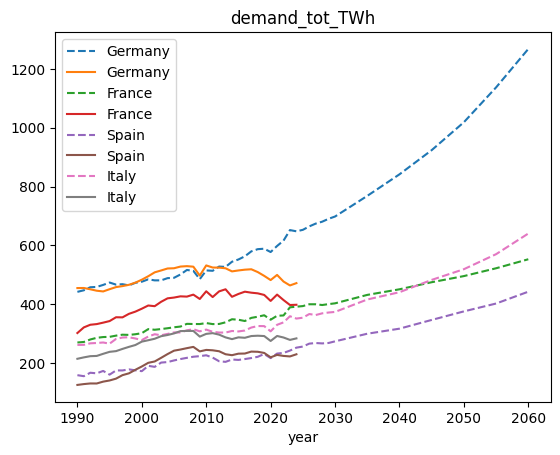

In [61]:
fig, ax = plt.subplots()


for country in ["Germany", "France", "Spain", "Italy"]:
#for country in ["Austria", "Belgium", "Sweden", "Norway"]:
    val_preds.predictions[country, :].plot(ax=ax, label=country, style="--")
    panel.demand_tot_TWh[country, :].plot(ax=ax, label=country)

ax.legend()
ax.set_title("demand_tot_TWh")
plt.show()

# New Model

In [62]:
formula = "ln_demand_ind_TWh ~ ln_pop + ln_gdp_pc + ln_industry_gva + eii_share_Percent + ln_energy_intensity"

# Considering the effect inside each country, but also the Time relevant effects for the Whole europe, like climate changes etc.
#m_PanelOLS = PanelOLS.from_formula(formula + " + EntityEffects + TimeEffects", data=train).fit(
m_PanelOLS_ind = PanelOLS.from_formula(formula, data=train).fit(    
    cov_type="clustered", cluster_entity=True#,  cluster_time=True
)

In [63]:
val_preds = m_PanelOLS_ind.predict(panel[["ln_pop", "ln_gdp_pc", "ln_industry_gva", "eii_share_Percent", "ln_energy_intensity"]])
val_preds = np.exp(val_preds)
val_preds

predictions
country year             
Austria 1990    24.040871
        1991    24.111958
        1992    24.400390
        1993    24.883831
        1994    25.011797
...                   ...
Sweden  2040    28.457619
        2045    28.707297
        2050    29.117986
        2055    29.643856
        2060    30.100940

[1222 rows x 1 columns]

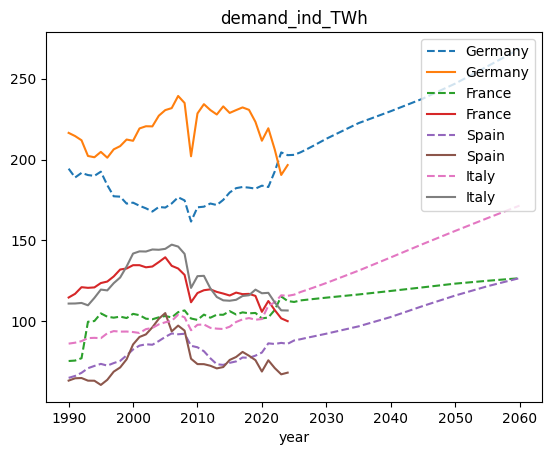

In [64]:
fig, ax = plt.subplots()


for country in ["Germany", "France", "Spain", "Italy"]:
#for country in ["Austria", "Belgium", "Sweden", "Norway"]:
    val_preds.predictions[country, :].plot(ax=ax, label=country, style="--")
    panel.demand_ind_TWh[country, :].plot(ax=ax, label=country)

ax.legend()
ax.set_title("demand_ind_TWh")
plt.show()

## Three-Sector Panel Demand Models
Three separate `PanelOLS` models (no entity/time effects) for **Industry**, **Transport**, and **Others** demand.  
- **Backtest**: model trained on `1990 – (BACKTEST_START-1)`, evaluated on `BACKTEST_START – 2024`  
- **Projection**: model re-trained on all historical data, projected to `2025 – 2060`

In [65]:
# ── Modify the formulas and backtest start year here ─────────────────────────

BACKTEST_START = 2018

formula_ind = (
    "demand_ind_TWh ~ "
    #"ln_pop + ln_gdp_pc + ln_industry_gva + eii_share_Percent + ln_energy_intensity"
    "population_Mio + gdp_per_capita_USD  + eii_share_Percent + industry_va_MioEUR + energy_intensity_KGOE_per_EUR_PPS"
)

formula_tra = (
    "demand_tra_TWh ~ "
    "population_Mio + gdp_per_capita_USD + energy_intensity_KGOE_per_EUR_PPS"
)

formula_oth = (
    "demand_oth_TWh ~ "
    "population_Mio + gdp_per_capita_USD + hdd_DegreesC + cdd_DegreesC" #+ ln_energy_intensity"
)

# ─────────────────────────────────────────────────────────────────────────────
print("Formulas defined.")
print(f"  Industry : {formula_ind}")
print(f"  Transport: {formula_tra}")
print(f"  Others   : {formula_oth}")

Formulas defined.
  Industry : demand_ind_TWh ~ population_Mio + gdp_per_capita_USD  + eii_share_Percent + industry_va_MioEUR + energy_intensity_KGOE_per_EUR_PPS
  Transport: demand_tra_TWh ~ population_Mio + gdp_per_capita_USD + energy_intensity_KGOE_per_EUR_PPS
  Others   : demand_oth_TWh ~ population_Mio + gdp_per_capita_USD + hdd_DegreesC + cdd_DegreesC


In [66]:
# ── Data splits ───────────────────────────────────────────────────────────────
# hist / proj are already defined above; re-derive to be safe
hist = panel[panel["demand_ind_TWh"].notna()].copy()
proj = panel[panel["demand_ind_TWh"].isna()].copy()

bt_train = hist[hist.index.get_level_values("year") < BACKTEST_START]
bt_test  = hist[hist.index.get_level_values("year") >= BACKTEST_START]

print(f"Backtest train : 1990 – {BACKTEST_START - 1}  ({len(bt_train)} obs)")
print(f"Backtest test  : {BACKTEST_START} – {hist.index.get_level_values('year').max()}  ({len(bt_test)} obs)")
print(f"Future proj    : {proj.index.get_level_values('year').min()} – {proj.index.get_level_values('year').max()}  ({len(proj)} obs)")

Backtest train : 1990 – 2017  (728 obs)
Backtest test  : 2018 – 2024  (182 obs)
Future proj    : 2025 – 2060  (312 obs)


In [ ]:
# ── Helper functions ──────────────────────────────────────────────────────────

def get_rhs_vars(formula: str) -> list[str]:
    """Return the RHS variable names from a 'y ~ x1 + x2 + ...' formula string."""
    rhs = formula.split("~")[1].strip()
    return [v.strip() for v in rhs.split("+") if v.strip()]

def fit_panel(formula: str, data) -> object:
    """Fit a PanelOLS model (no entity/time effects) with entity-clustered SEs."""
    return PanelOLS.from_formula(formula, data=data).fit(
        cov_type="clustered", cluster_entity=True
    )
    
def predict_exp(model, data, formula: str):
    """
    Predict on `data` using feature columns from `formula`, then
    back-transform from log scale.  Returns a Series indexed by (country, year).
    """
    cols = get_rhs_vars(formula)
    preds = model.predict(data[cols])
    return np.exp(preds["predictions"])

def predict_normal(model, data, formula: str):
    """
    Predict on `data` using feature columns from `formula`, then
    back-transform from log scale.  Returns a Series indexed by (country, year).
    """
    cols = get_rhs_vars(formula)
    preds = model.predict(data[cols])
    return preds
    #return np.exp(preds["predictions"])


# ── Fit models ────────────────────────────────────────────────────────────────

# Backtest models – trained on pre-BACKTEST_START data only
m_ind_bt = fit_panel(formula_ind, bt_train)
m_tra_bt = fit_panel(formula_tra, bt_train)
m_oth_bt = fit_panel(formula_oth, bt_train)

# Production models – trained on the full historical dataset
m_ind = fit_panel(formula_ind, hist)
m_tra = fit_panel(formula_tra, hist)
m_oth = fit_panel(formula_oth, hist)

print("All six models fitted.")

All six models fitted.


In [68]:
print("=" * 60)
print("INDUSTRY MODEL")
print("=" * 60)
print(m_ind.summary)

print("\n" + "=" * 60)
print("TRANSPORT MODEL")
print("=" * 60)
print(m_tra.summary)

print("\n" + "=" * 60)
print("OTHERS MODEL")
print("=" * 60)
print(m_oth.summary)

INDUSTRY MODEL
                          PanelOLS Estimation Summary                           
Dep. Variable:         demand_ind_TWh   R-squared:                        0.9512
Estimator:                   PanelOLS   R-squared (Between):              0.9737
No. Observations:                 910   R-squared (Within):              -2.0292
Date:                Wed, May 06 2026   R-squared (Overall):              0.9512
Time:                        12:10:18   Log-likelihood                   -3665.2
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      3525.8
Entities:                          26   P-value                           0.0000
Avg Obs:                       35.000   Distribution:                   F(5,905)
Min Obs:                       35.000                                           
Max Obs:                       35.000   F-statistic (robust):             2648.6
             

In [69]:
# ── Generate predictions ──────────────────────────────────────────────────────

# In-sample fit of the backtest model on the pre-backtest period (1990 – BACKTEST_START-1)
pre_bt_pred_ind = predict_exp(m_ind_bt, bt_train, formula_ind)
pre_bt_pred_tra = predict_exp(m_tra_bt, bt_train, formula_tra)
pre_bt_pred_oth = predict_exp(m_oth_bt, bt_train, formula_oth)

# Out-of-sample backtest (BACKTEST_START – last historical year)  ← same backtest model
bt_pred_ind = predict_exp(m_ind_bt, bt_test, formula_ind)
bt_pred_tra = predict_exp(m_tra_bt, bt_test, formula_tra)
bt_pred_oth = predict_exp(m_oth_bt, bt_test, formula_oth)

# Future projection (2025 – 2060) ← production model trained on full history
fut_pred_ind = predict_exp(m_ind, proj, formula_ind)
fut_pred_tra = predict_exp(m_tra, proj, formula_tra)
fut_pred_oth = predict_exp(m_oth, proj, formula_oth)

print("Predictions ready.")
print(f"  Pre-backtest fit rows : {len(pre_bt_pred_ind)}")
print(f"  Backtest rows         : {len(bt_pred_ind)}")
print(f"  Projection rows       : {len(fut_pred_ind)}")

Predictions ready.
  Pre-backtest fit rows : 728
  Backtest rows         : 182
  Projection rows       : 312


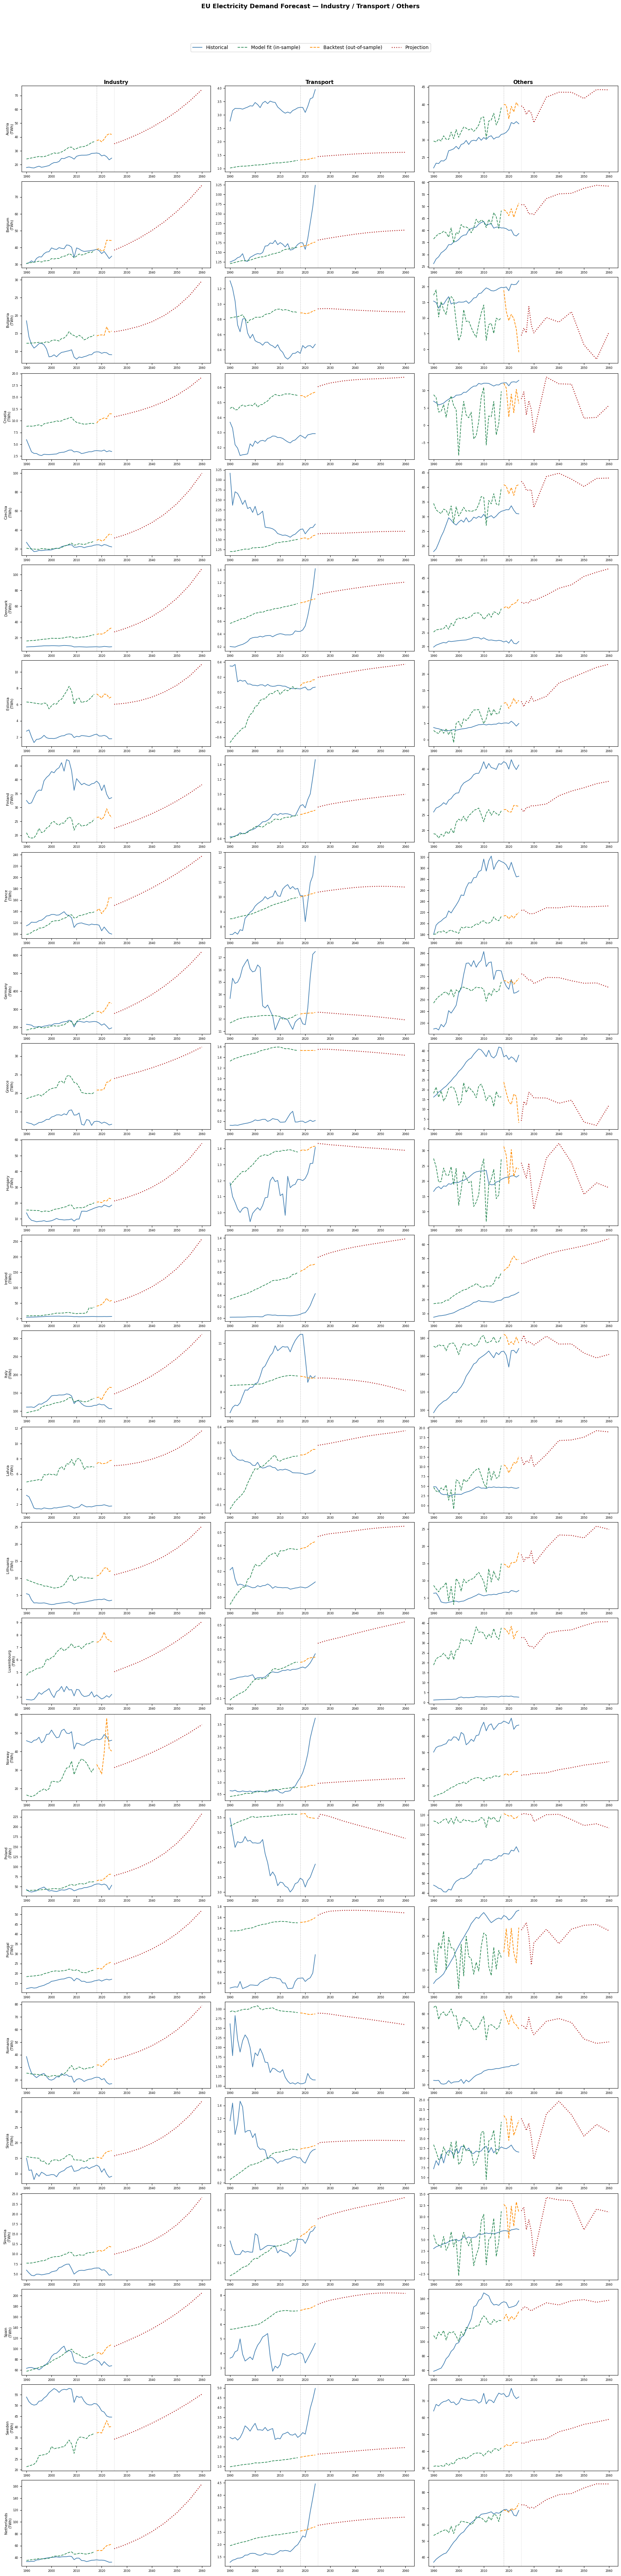

Figure saved → demand_forecast_26x3.png


In [70]:
# ── 26 × 3 forecast grid ─────────────────────────────────────────────────────

sectors = [
    ("Industry",  "demand_ind_TWh", pre_bt_pred_ind, bt_pred_ind, fut_pred_ind),
    ("Transport", "demand_tra_TWh", pre_bt_pred_tra, bt_pred_tra, fut_pred_tra),
    ("Others",    "demand_oth_TWh", pre_bt_pred_oth, bt_pred_oth, fut_pred_oth),
]

n = len(countries)
fig, axes = plt.subplots(
    nrows=n, ncols=3,
    figsize=(18, n * 2.8),
    constrained_layout=True,
)

for row, country in enumerate(countries):
    for col, (sector_name, actual_col, pre_preds, bt_preds, fut_preds) in enumerate(sectors):
        ax = axes[row, col]

        # ── Historical actuals ──────────────────────────────────────────────
        try:
            actuals = hist[actual_col].xs(country, level="country")
            ax.plot(actuals.index, actuals.values,
                    color="steelblue", lw=1.4, zorder=2, label="Historical")
        except KeyError:
            pass

        # ── Model in-sample fit (1990 – BACKTEST_START-1) ───────────────────
        # Uses the same backtest model → directly comparable to the backtest line
        try:
            pre = pre_preds.xs(country, level="country")
            ax.plot(pre.index, pre.values,
                    "--", color="seagreen", lw=1.4, zorder=3, label="Model fit (in-sample)")
        except KeyError:
            pass

        # ── Out-of-sample backtest (BACKTEST_START – 2024) ─────────────────
        try:
            bt = bt_preds.xs(country, level="country")
            ax.plot(bt.index, bt.values,
                    "--", color="darkorange", lw=1.4, zorder=3, label="Backtest (out-of-sample)")
        except KeyError:
            pass

        # ── Future projection (2025 – 2060) ────────────────────────────────
        try:
            fut = fut_preds.xs(country, level="country")
            ax.plot(fut.index, fut.values,
                    ":", color="firebrick", lw=1.8, zorder=3, label="Projection")
        except KeyError:
            pass

        # ── Reference lines ─────────────────────────────────────────────────
        ax.axvline(x=BACKTEST_START, color="gray", lw=0.7, ls="--", alpha=0.5)
        ax.axvline(x=2025,           color="gray", lw=0.7, ls=":",  alpha=0.5)

        # ── Labels & formatting ─────────────────────────────────────────────
        if row == 0:
            ax.set_title(sector_name, fontsize=11, fontweight="bold", pad=4)
        if col == 0:
            ax.set_ylabel(f"{country}\n(TWh)", fontsize=7.5, labelpad=2)
        ax.tick_params(axis="both", labelsize=6)
        ax.set_xlim(left=1988)

# ── Shared legend above the grid ─────────────────────────────────────────────
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=4,
    fontsize=10,
    frameon=True,
    bbox_to_anchor=(0.5, 1.015),
)
fig.suptitle(
    "EU Electricity Demand Forecast — Industry / Transport / Others",
    fontsize=13, fontweight="bold", y=1.03,
)

plt.savefig("demand_forecast_26x3.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved → demand_forecast_26x3.png")